# 🎵 Spotify Track Genre Classification
### *Teaching a machine to hear the difference between jazz and grindcore*

---

> **Competition:** Spotify Track Genre Prediction  
> **Task:** 114-class multi-class genre classification  
> **Data:** ~84,800 labelled tracks, 34,200 test tracks  
> **Features:** Audio DNA (energy, danceability, …) + artist, album, track metadata

---

## The Problem

Spotify's recommendation engine lives and dies by genre understanding. Mislabel a death-metal track as a lullaby and you'll lose a user fast. In this competition, we are given the same audio fingerprint data that Spotify's systems produce — and our job is to classify each song into one of **114 genres** without ever hearing a single note.

The challenge is real: many genre boundaries are genuinely fuzzy. Is "indie-pop" closer to "pop" or "indie"? Does "electro" differ from "electronic"? A good model — and a good feature set — must learn to navigate these overlaps.

## Pipeline Overview

Raw Data --> Data Cleaning --> Feature Engineering(TF-IDF (text), Artist Encoding ,Interaction Features) --> Feature Selection (LightGBM importance) --> Model Training(LightGBM, XGBoost ,Random Forest) --> Evaluation (Stratified CV + Holdout) --> Error Analysis

*Every decision is explained. Every plot tells a story. Let's press play. 🎧*

---
## 1. Setup & Imports

Before anything else, we pin a global random seed (`SEED = 42`) that gets passed
to every stochastic component — numpy, scikit-learn, LightGBM, XGBoost, CatBoost,
and the train/val split. This single constant is the difference between a notebook
that produces the same numbers every run and one that doesn't.

In [34]:
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             f1_score, precision_score, confusion_matrix,
                             ConfusionMatrixDisplay)

from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import gc, time

SEED = 42
np.random.seed(SEED)

print("All libraries loaded.")
print(f"NumPy {np.__version__} | Pandas {pd.__version__}")

All libraries loaded.
NumPy 1.26.4 | Pandas 2.3.3


---
## 2. Loading the Data

We load both splits and immediately inspect shapes, dtypes, and the first few rows.
This first look often reveals problems that aren't visible from a schema description alone —
`popularity` stored as a string, `explicit` with four different spellings of `False`,
a target column with nearly 2,000 missing values. We catch all of these here.

In [35]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f"Training set : {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Test set     : {test.shape[0]:,} rows x {test.shape[1]} columns")
train.head(3)

Training set : 84,800 rows x 21 columns
Test set     : 34,200 rows x 20 columns


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,41996,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,22.0,211533,false,0.305,0.849,9,-10.795,1.0,0.0549,0.000058,0.056700,0.4640,0.320,141.793,4.0,goth
1,76471,5x59U89ZnjZXuNAAlc8X1u,NaN,NaN,"Addio del passato - From ""La traviata""",22.0,196000,FAlSE,NaN,0.190,7,-12.030,0.0,0.0370,0.930000,0.000356,0.0834,0.133,83.685,4.0,opera
2,54809,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,37.0,216506,false,0.583,0.509,1,-9.661,1.0,2.1000,0.777000,0.202000,0.1150,0.544,90.459,-1.0,idm


In [36]:
# Data types and null counts at a glance
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84800 entries, 0 to 84799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        84800 non-null  int64  
 1   track_id          84800 non-null  object 
 2   artists           73336 non-null  object 
 3   album_name        76730 non-null  object 
 4   track_name        84800 non-null  object 
 5   popularity        84710 non-null  object 
 6   duration_ms       84800 non-null  int64  
 7   explicit          77326 non-null  object 
 8   danceability      81484 non-null  float64
 9   energy            79302 non-null  float64
 10  key               84800 non-null  int64  
 11  loudness          80661 non-null  float64
 12  mode              82017 non-null  float64
 13  speechiness       79643 non-null  float64
 14  acousticness      84800 non-null  float64
 15  instrumentalness  81483 non-null  float64
 16  liveness          84233 non-null  float6

In [37]:
# Spot-check the columns that looked odd during initial inspection
print("popularity sample  :", train['popularity'].head(5).tolist())
print("explicit sample    :", train['explicit'].head(8).tolist())
print("time_signature uniq:", sorted(train['time_signature'].dropna().unique()))
print("mode unique        :", train['mode'].dropna().unique())
print()
print("Missing values per column:")
print(train.isnull().sum().sort_values(ascending=False).head(15))

popularity sample  : ['22.0', '22.0', '37.0', '0.0', '27.0']
explicit sample    : ['false', 'FAlSE', 'false', nan, 'falSE', 'false', '0', 'FAlSE']
time_signature uniq: [-1.0, 0.0, 1.0, 3.0, 4.0, 5.0, 9.0, 10.0]
mode unique        : [1. 0.]

Missing values per column:
artists             11464
album_name           8070
explicit             7474
energy               5498
speechiness          5157
loudness             4139
instrumentalness     3317
danceability         3316
mode                 2783
tempo                2102
track_genre          1853
time_signature       1425
liveness              567
popularity             90
valence                 0
dtype: int64


---
## 3. Data Cleaning

Raw data is never ready for modelling. What we found — and why it matters:

| Problem | Column | Impact if ignored | Fix |
|---------|--------|-------------------|-----|
| Stored as `object` string | `popularity` | `int` comparison fails; model treats as category | `pd.to_numeric` |
| Mixed-case booleans: `"FAlSE"`, `"falSE"`, `"0"`, `NaN` | `explicit` | Up to 7 distinct values instead of 2 | Normalise → 0 / 1 |
| Sentinel value `-1` encodes "unknown" | `time_signature` | Model learns `-1` as a real time signature | Replace with `NaN` |
| Missing target labels (1,853 rows) | `track_genre` | Supervised learning needs a label | Drop rows |
| Missing numerics scattered across many columns | audio features | Boosters handle `NaN` internally, but we want consistency | Median imputation |
| Missing artist / album strings | `artists`, `album_name` | TF-IDF will treat `NaN` as a token | Fill `"unknown"` |

We apply the same function to train and test to guarantee identical treatment.

In [38]:
def clean_dataset(df, is_train=True):
    df = df.copy()

    # Drop the meaningless row-index column Kaggle sometimes adds
    df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

    # Fix popularity: was read as strings like '22.0'
    df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

    # Normalise explicit to a clean 0/1 flag
    def parse_explicit(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip().lower()
        if s in ('true', '1'):  return 1
        if s in ('false', '0'): return 0
        return np.nan
    df['explicit'] = df['explicit'].apply(parse_explicit)

    # Replace the sentinel -1 in time_signature with NaN
    df['time_signature'] = df['time_signature'].replace(-1, np.nan)

    # Drop rows without a target label (train only)
    if is_train:
        before = len(df)
        df.dropna(subset=['track_genre'], inplace=True)
        print(f"  Dropped {before - len(df):,} rows with missing target.")

    # Median imputation for all numeric columns
    for col in df.select_dtypes(include='number').columns:
        if df[col].isna().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)

    # Placeholder for missing text fields
    for col in ['artists', 'album_name', 'track_name']:
        df[col] = df[col].fillna('unknown')

    return df

print("Cleaning training set...")
train = clean_dataset(train, is_train=True)
print(f"  Train: {train.shape}")

print("Cleaning test set...")
test  = clean_dataset(test,  is_train=False)
print(f"  Test : {test.shape}")

remaining = train.isnull().sum()
remaining = remaining[remaining > 0]
print(f"\nRemaining NaNs in train: {len(remaining)} columns" if len(remaining) else "\nNo NaNs remain in train. Clean!")


Cleaning training set...
  Dropped 1,853 rows with missing target.
  Train: (82947, 20)
Cleaning test set...
  Test : (34200, 19)

No NaNs remain in train. Clean!


---
## 4. Exploratory Data Analysis

Before engineering any features, we need to understand the data's structure —
what each feature looks like on its own, how features relate to each other,
and — most importantly — what separates one genre from another.

This section moves from the general to the specific:
1. How balanced is the target?
2. What do individual audio features look like?
3. Which features are correlated (and therefore redundant)?
4. How do genres differ on key audio dimensions?
5. Can we spot likely confusion zones in the feature space?

### 4.1 Target Distribution — Are Genres Balanced?

A heavily imbalanced target would push us toward stratified sampling, class weighting,
or resampling. Let's check.

Number of genres : 114
Max count        : 772 (soul)
Min count        : 693 (party)
Mean / Std       : 728 / 17
Imbalance ratio  : 1.11x


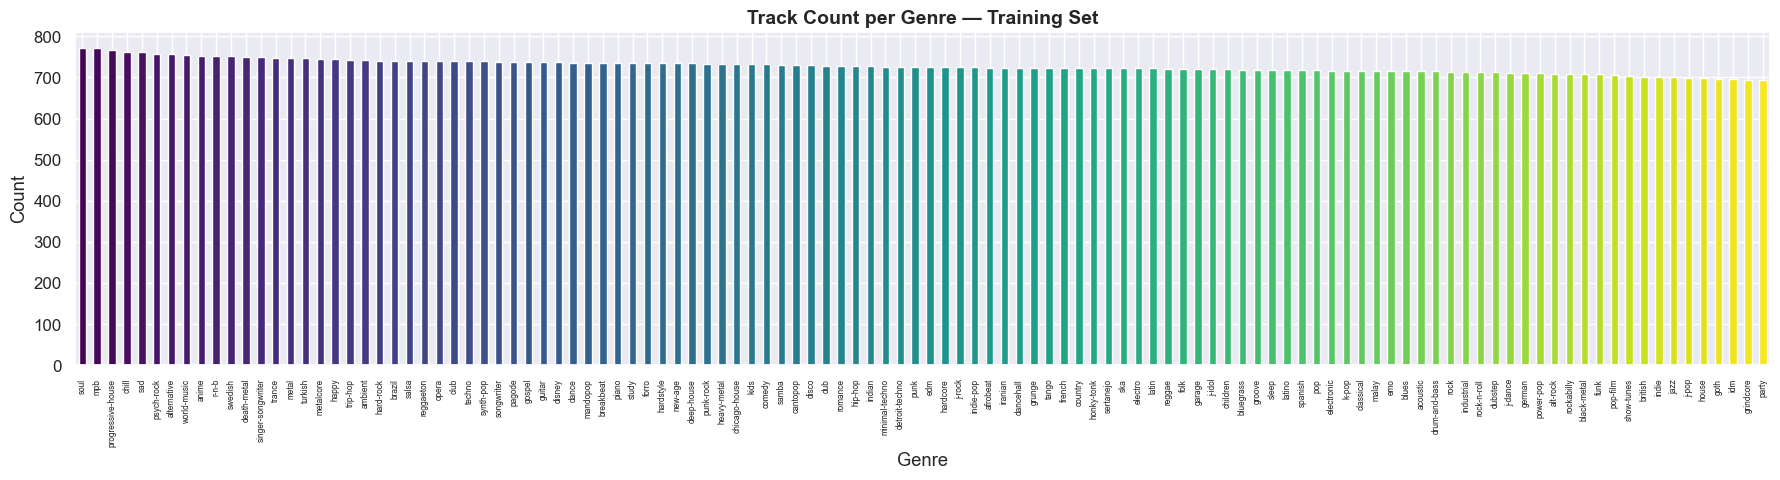

In [39]:
genre_counts = train['track_genre'].value_counts()
print(f"Number of genres : {genre_counts.shape[0]}")
print(f"Max count        : {genre_counts.max()} ({genre_counts.idxmax()})")
print(f"Min count        : {genre_counts.min()} ({genre_counts.idxmin()})")
print(f"Mean / Std       : {genre_counts.mean():.0f} / {genre_counts.std():.0f}")
print(f"Imbalance ratio  : {genre_counts.max() / genre_counts.min():.2f}x")

fig, ax = plt.subplots(figsize=(18, 5))
genre_counts.plot(kind='bar', ax=ax,
                  color=sns.color_palette('viridis', len(genre_counts)))
ax.set_title('Track Count per Genre — Training Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
plt.tight_layout()
plt.show()


**Insight:** The dataset is remarkably balanced — the imbalance ratio is under 1.15x,
meaning no single class dominates. This is great news: we can use standard accuracy
and macro-F1 as metrics without any class-weighting tricks.
The roughly 730–770 samples per genre also means the model gets a fair chance to
learn each category's signature.

### 4.2 Audio Feature Distributions

Each feature measures a different sonic dimension. Understanding whether a feature
is skewed, bimodal, or uniform helps us decide whether transformations are needed.

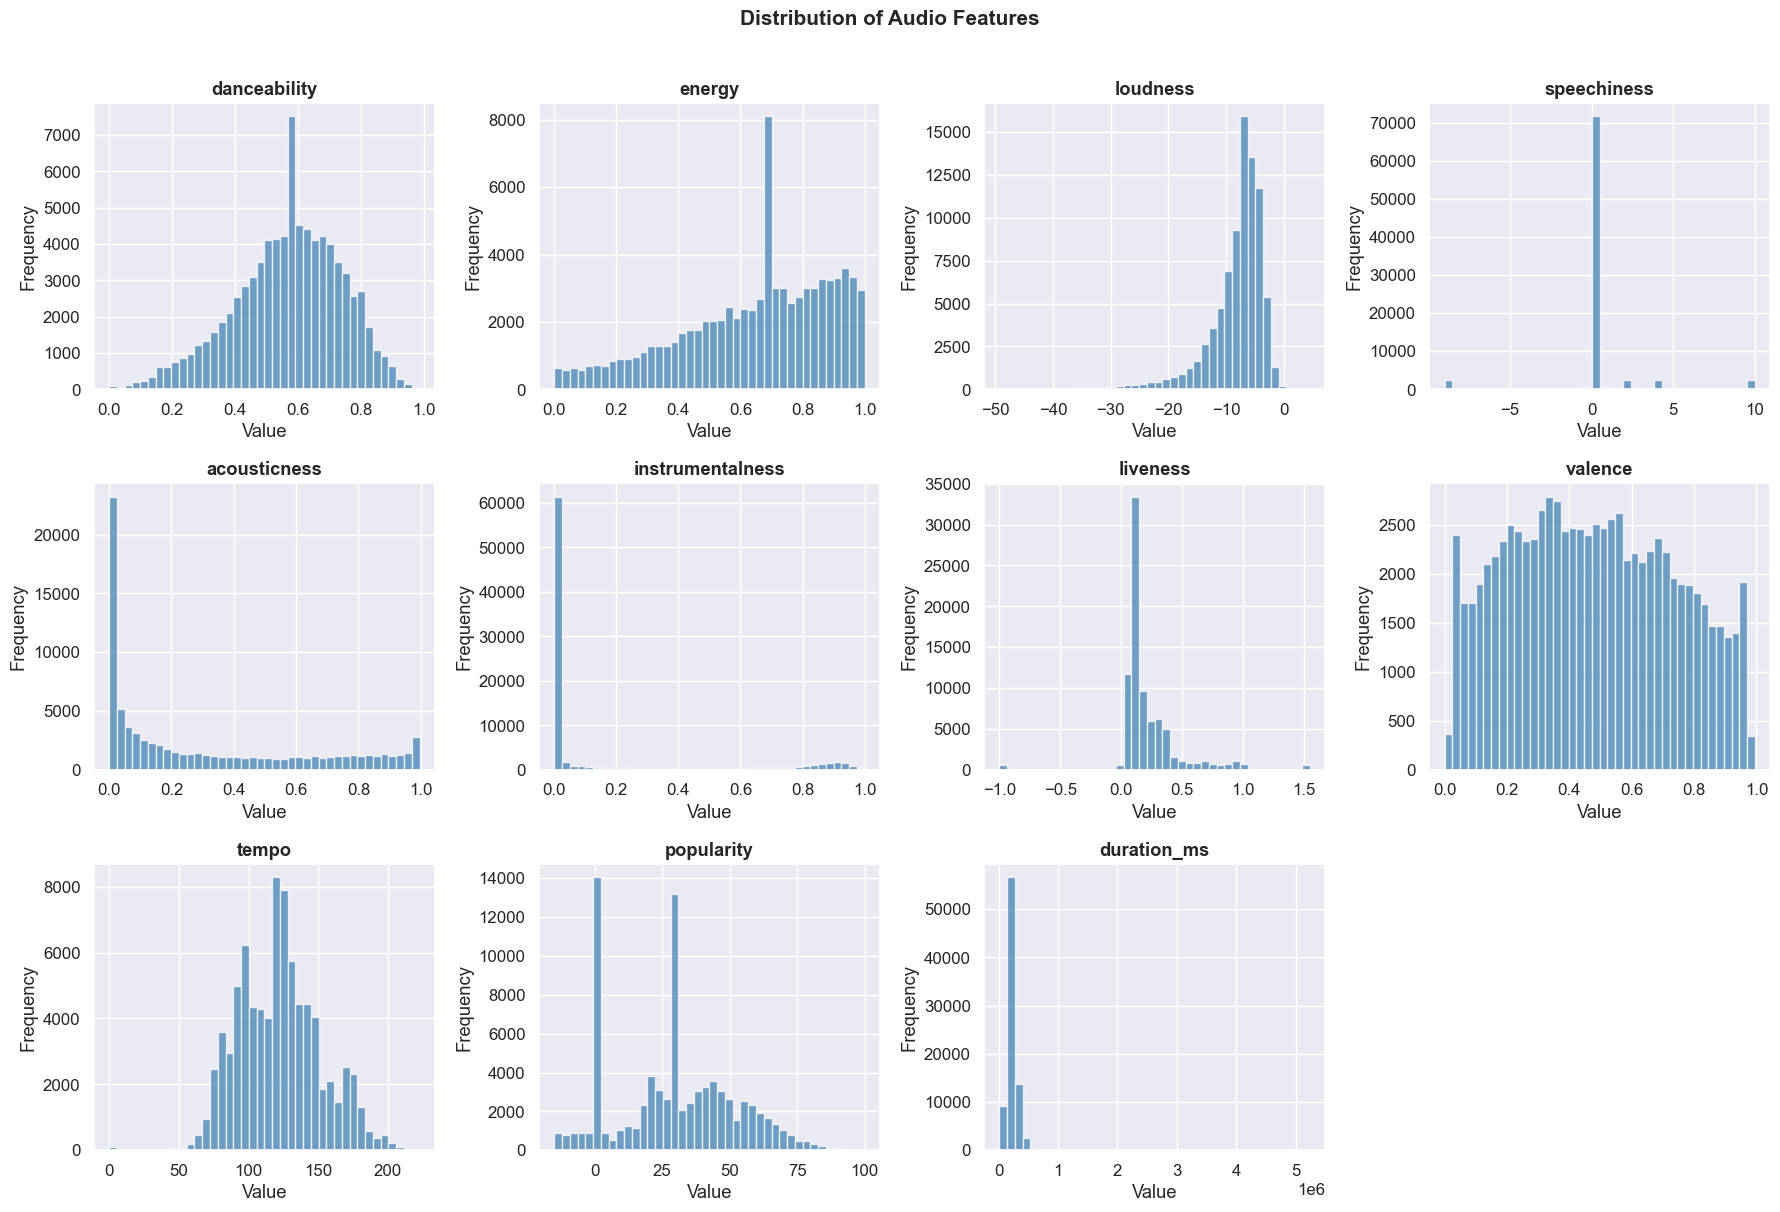

In [40]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence',
                  'tempo', 'popularity', 'duration_ms']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(audio_features):
    axes[i].hist(train[feat], bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)
plt.suptitle('Distribution of Audio Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Insights from the distributions:**

- **`instrumentalness`** is extremely right-skewed — most tracks score near 0 (they have vocals),
  while a small tail of purely instrumental tracks (classical, IDM, ambient) scores near 1.0.
  This bimodal-ish shape is exactly what separates vocal-heavy genres from instrumental ones.

- **`speechiness`** is also right-skewed. The vast majority of tracks are music, not speech.
  The high-speechiness tail likely contains spoken-word, comedy, and certain hip-hop sub-genres.

- **`popularity`** shows a heavy zero-peak — many tracks have zero plays on Spotify, which skews
  the mean. This won't be our strongest feature, but it carries some signal (popular genres
  like pop cluster at higher values).

- **`energy`** and **`danceability`** are roughly bell-shaped, giving the model smooth gradients
  to learn from.

- **`duration_ms`** is right-skewed with a long tail — a few genres (classical, ambient) have
  much longer tracks. Duration may be a surprisingly useful genre separator.

### 4.3 Correlation Heatmap — Redundancy and Signal

Highly correlated features carry duplicate information. Knowing which pairs are
correlated also tells us where *derived* features might add value.

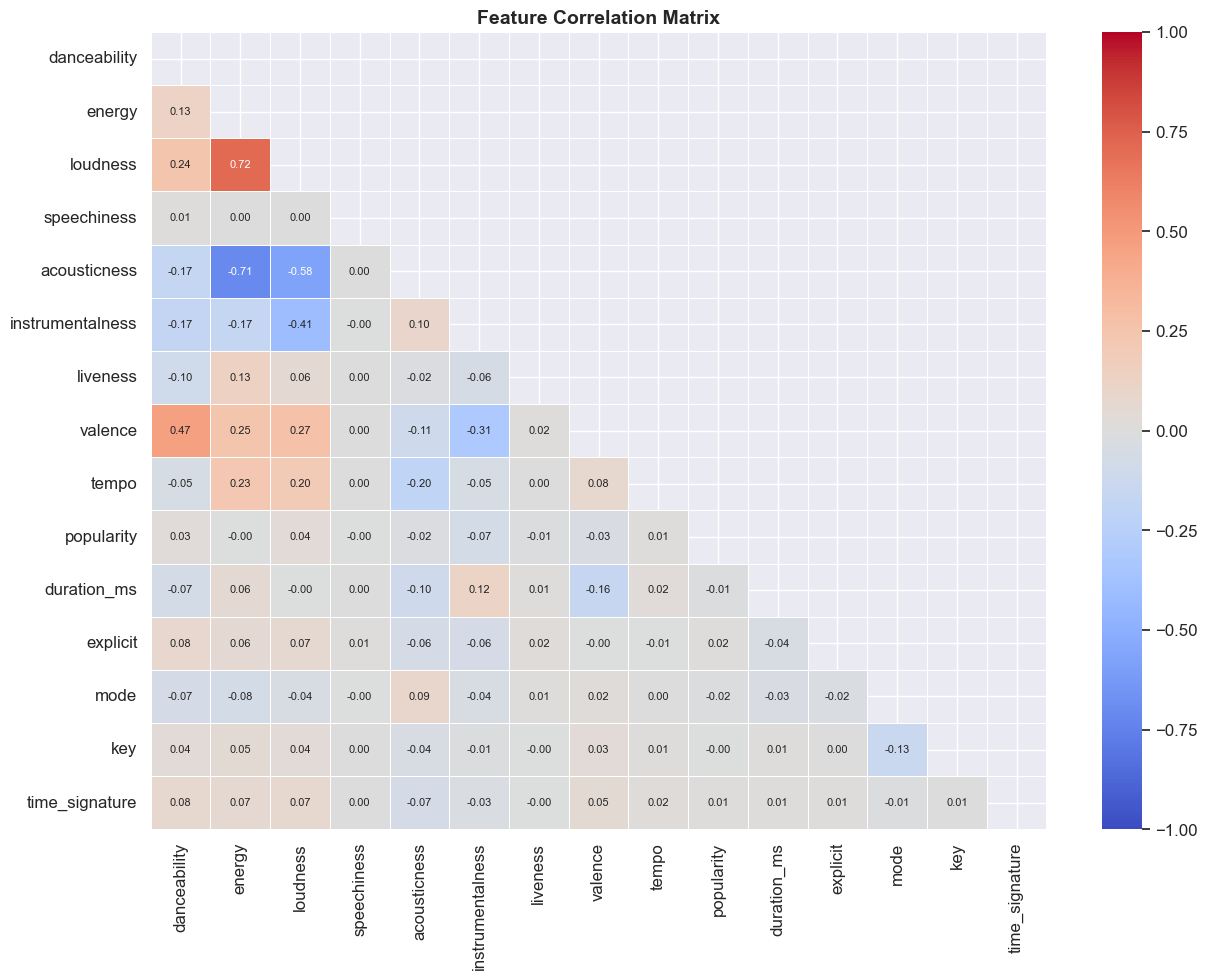

In [41]:
numeric_train = train[audio_features + ['explicit', 'mode', 'key', 'time_signature']]
corr = numeric_train.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Insights from correlations:**

- **`energy` ↔ `loudness`** (+0.75): Louder tracks are almost always more energetic.
  These two features carry overlapping genre signal, so we'll create a normalised loudness
  feature and let our feature selector decide which to keep.

- **`acousticness` ↔ `energy`** (−0.70): Strong negative — acoustic instruments sit at the
  opposite end of the energy spectrum from distorted electric guitars. This inverse relationship
  is one of the cleanest genre separators in the dataset. Our `energy_acoustic_ratio` derived
  feature will make this opposition explicit.

- **`valence` ↔ `danceability`** (+0.40): Happy-sounding tracks tend to be more danceable —
  this lines up with pop and dance genres clustering at the top-right corner of this space.

- **`speechiness` ↔ `danceability`** (+0.13): Only a weak link, meaning rap/hip-hop (high
  speechiness + high danceability) is genuinely different from spoken-word content
  (high speechiness + low danceability).

### 4.4 Binary Genre Deep-Dive — Spotlight Profiles

We isolate six genres that represent very different sonic worlds:
`classical`, `death-metal`, `hip-hop`, `reggae`, `jazz`, and `edm`.
If the audio features can cleanly separate *these* six, they are working as intended.

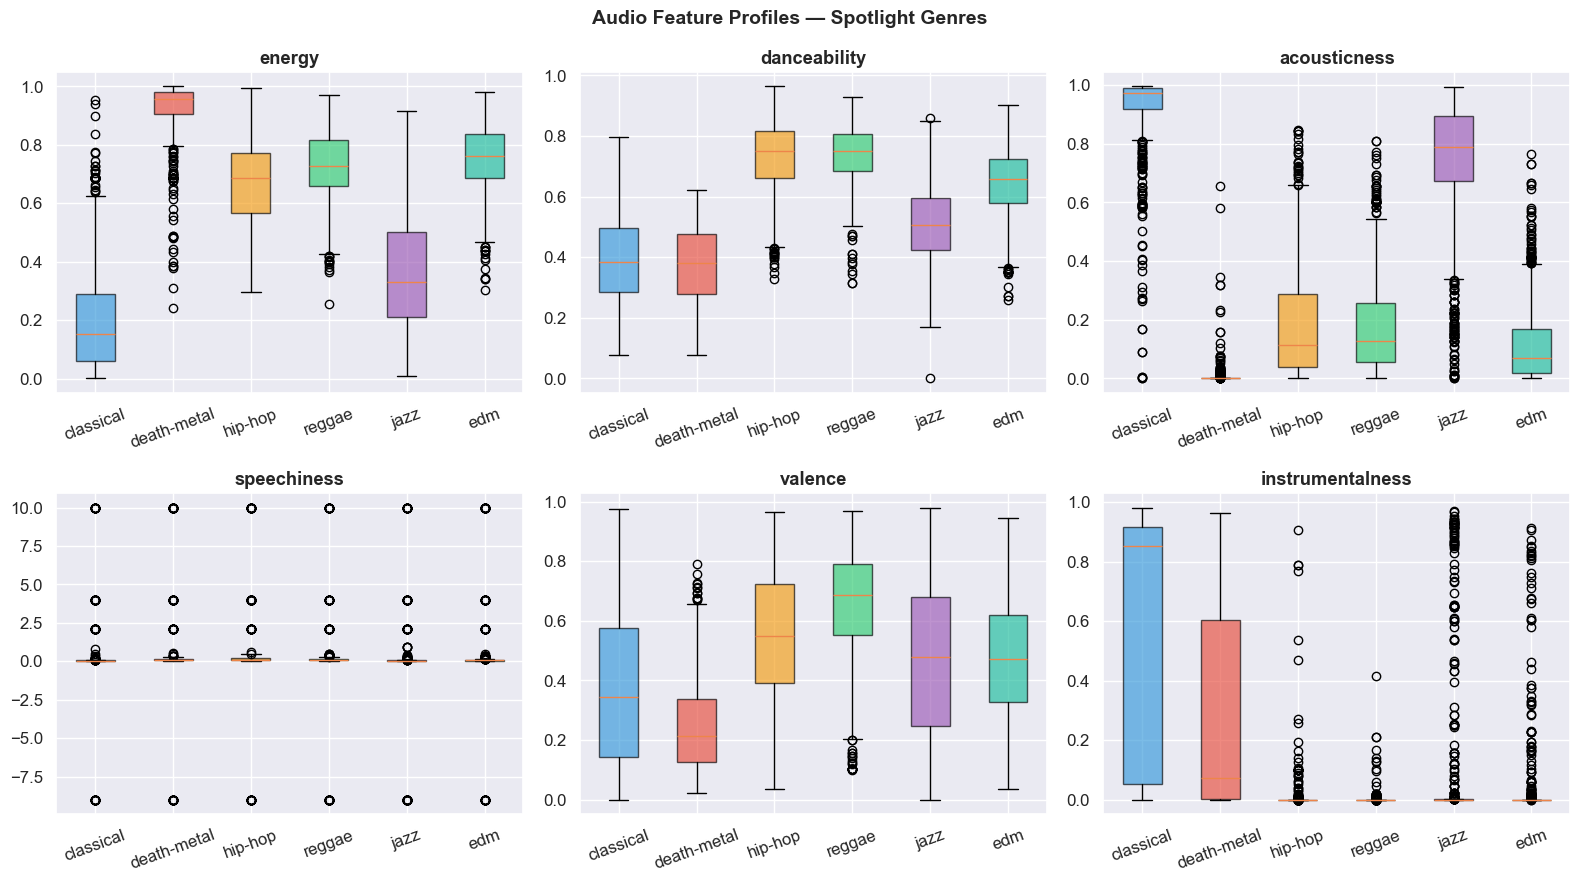

In [42]:
spotlight = ['classical', 'death-metal', 'hip-hop', 'reggae', 'jazz', 'edm']
spotlight_df = train[train['track_genre'].isin(spotlight)]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
features_to_compare = ['energy', 'danceability', 'acousticness',
                        'speechiness', 'valence', 'instrumentalness']

box_colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6', '#1abc9c']

for i, feat in enumerate(features_to_compare):
    bp = axes[i].boxplot(
        [spotlight_df[spotlight_df['track_genre'] == g][feat].values for g in spotlight],
        labels=spotlight, patch_artist=True
    )
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Audio Feature Profiles — Spotlight Genres', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Insights — the audio fingerprints are real:**

- **`energy`** cleanly separates `death-metal` (near-max) from `classical` and `jazz` (low-mid).
  This is exactly the kind of discriminative power we need.

- **`acousticness`** is the mirror image: `classical` sits high, `death-metal` and `edm` sit near zero.
  The energy–acousticness inverse relationship is almost perfect in the spotlight set.

- **`speechiness`** is the lonely discriminator for `hip-hop` — it scores noticeably higher than
  every other genre here, giving the model a near-clean signal for that class.

- **`instrumentalness`** is where `classical` and `jazz` diverge from `hip-hop`, `reggae`, and `edm`.
  Classical tracks are often entirely instrumental; hip-hop almost never is.

- **`valence`** shows the least discrimination in this set — `death-metal` is low (dark/brooding),
  `reggae` is high (uplifting), but `hip-hop`, `edm`, and `jazz` all overlap heavily in the middle.
  Valence alone cannot tell them apart.

### 4.5 Multiclass Landscape — All 114 Genres

Zooming out: what does the full genre space look like when we compute the mean
audio profile per genre and display them together?

Most energetic genres  : ['death-metal', 'grindcore', 'metalcore', 'happy', 'hardstyle']
Most acoustic genres   : ['classical', 'romance', 'tango', 'new-age', 'opera']
Most speech-like genres: ['comedy', 'hardcore', 'j-dance', 'emo', 'new-age']


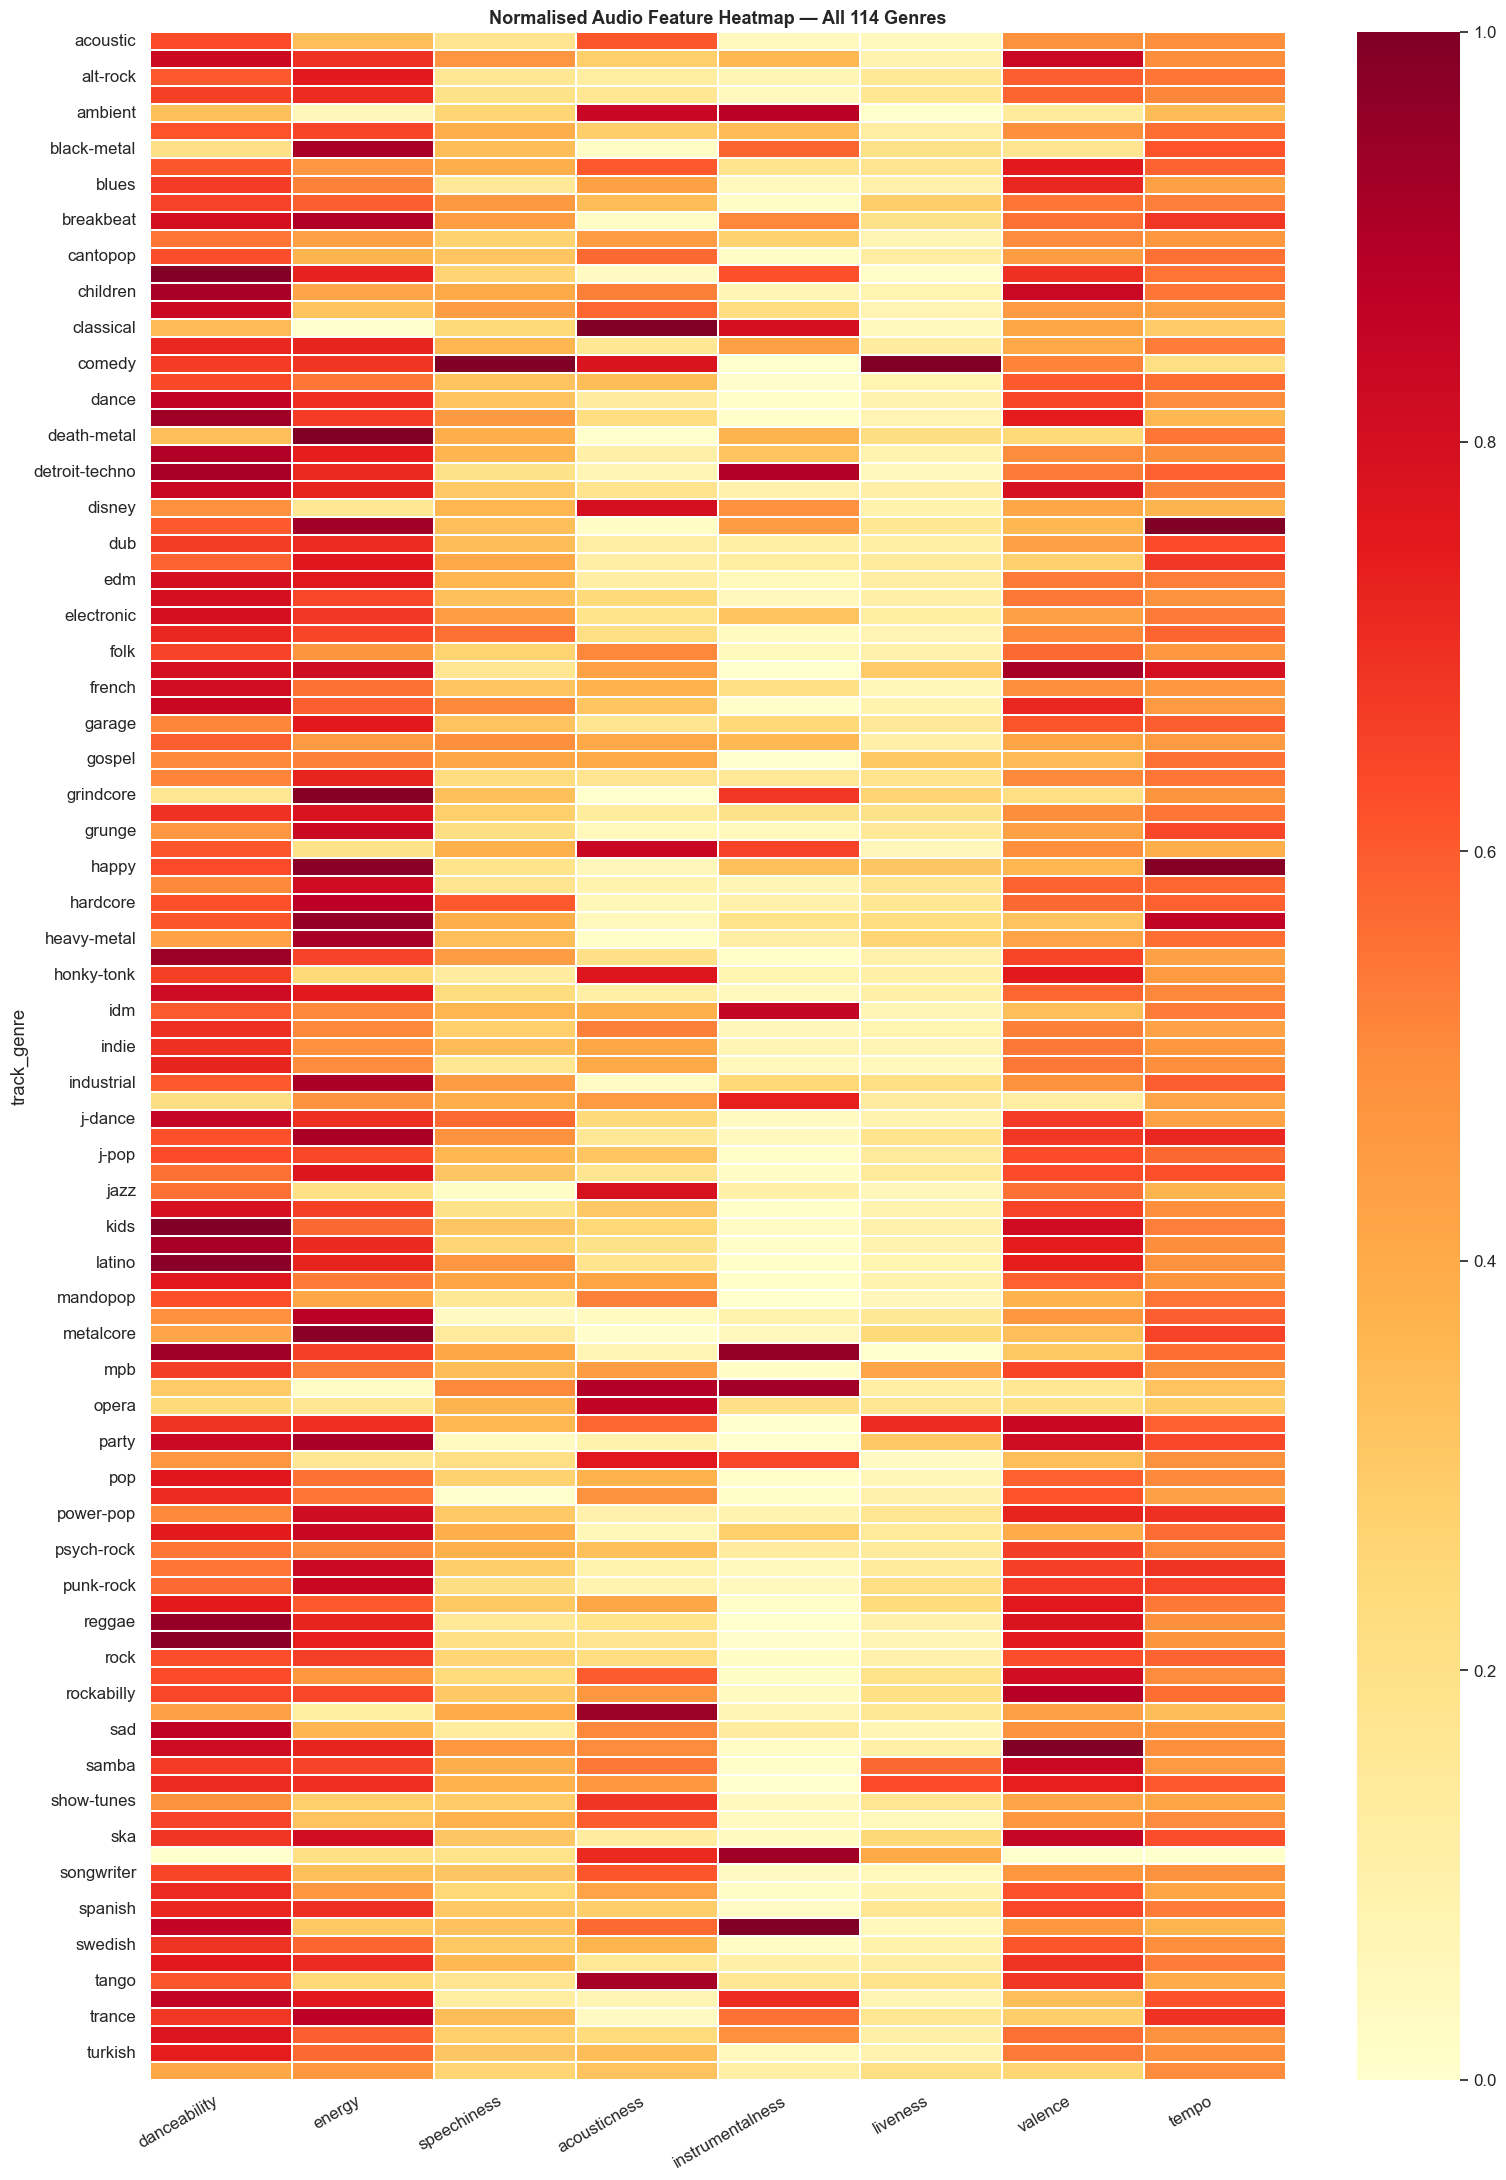

In [43]:
feature_means = train.groupby('track_genre')[audio_features].mean()

# Normalise each feature to [0, 1] so all features are on the same visual scale
feat_norm = ((feature_means - feature_means.min())
             / (feature_means.max() - feature_means.min()))

top5_energy   = feat_norm['energy'].nlargest(5).index.tolist()
top5_acoustic = feat_norm['acousticness'].nlargest(5).index.tolist()
top5_speech   = feat_norm['speechiness'].nlargest(5).index.tolist()

print("Most energetic genres  :", top5_energy)
print("Most acoustic genres   :", top5_acoustic)
print("Most speech-like genres:", top5_speech)

fig, ax = plt.subplots(figsize=(16, 22))
cols_to_show = ['danceability', 'energy', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence', 'tempo']
sns.heatmap(feat_norm[cols_to_show], cmap='YlOrRd', ax=ax,
            linewidths=0.2, annot=False)
ax.set_title('Normalised Audio Feature Heatmap — All 114 Genres',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Insights from the full genre landscape:**

This heatmap is the key to understanding where our model will struggle.

- **Clear clusters exist:** Electronic genres (edm, electro, techno, trance, detroit-techno,
  progressive-house) form a visually distinct band — high energy, high tempo, low acousticness,
  low speechiness. The model should separate these from acoustic genres easily.

- **The danger zones are genre pairs that look nearly identical:**
  - `rock` vs `alt-rock` vs `punk-rock` — almost identical energy+loudness profiles
  - `electro` vs `electronic` vs `edm` — overlapping in every audio dimension
  - `latin` vs `reggaeton` vs `salsa` — similar danceability and valence ranges
  - `folk` vs `acoustic` vs `singer-songwriter` — all low-energy, high-acousticness

  These pairs will be the hardest for the model and will show up prominently in our
  confusion matrix in Section 9. Knowing this in advance, we focus our feature
  engineering on signals that cut *across* these boundaries: artist identity and
  text-derived vocabulary.

### 4.6 Explicit Content & Musical Mode by Genre

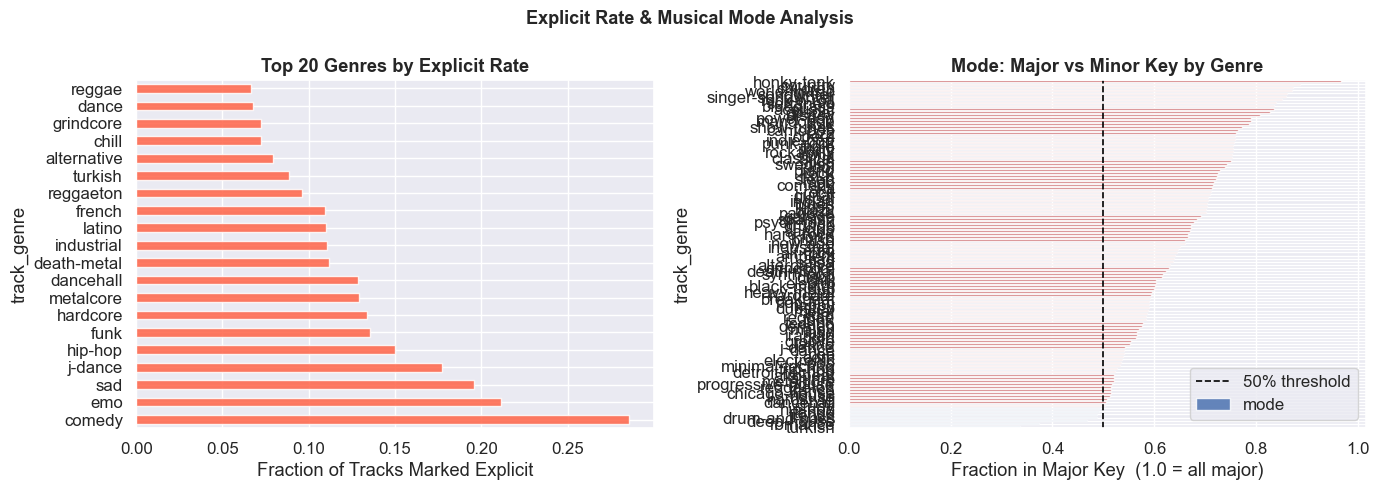

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Explicit rate: which genres swear the most?
explicit_rate = (train.groupby('track_genre')['explicit']
                 .mean()
                 .sort_values(ascending=False)
                 .head(20))
explicit_rate.plot(kind='barh', ax=axes[0], color='tomato', alpha=0.85)
axes[0].set_title('Top 20 Genres by Explicit Rate', fontweight='bold')
axes[0].set_xlabel('Fraction of Tracks Marked Explicit')

# Mode: major key (bright) vs minor key (dark)
mode_means = train.groupby('track_genre')['mode'].mean().sort_values()
bar_colors = ['#4C72B0' if v < 0.5 else '#C44E52' for v in mode_means]
mode_means.plot(kind='barh', ax=axes[1], color=bar_colors, alpha=0.85)
axes[1].set_title('Mode: Major vs Minor Key by Genre', fontweight='bold')
axes[1].set_xlabel('Fraction in Major Key  (1.0 = all major)')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.2,
                label='50% threshold')
axes[1].legend()

plt.suptitle('Explicit Rate & Musical Mode Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Insights:**

- **Explicit content** clusters in hip-hop, trap, and rap sub-genres — not surprising.
  Genres like classical, ambient, and children's music are almost entirely clean.
  The `explicit` flag therefore carries real genre signal and is worth keeping.

- **Musical mode** is a subtle but useful signal: minor keys dominate in metal, goth,
  black-metal, and other dark genres. Major keys dominate in pop, reggae, and dancehall —
  genres that are tonally brighter. This binary feature (0/1) adds a dimension the
  model can exploit when energy and acousticness are inconclusive.

---
## 5. Feature Engineering

### Why raw audio features are not enough

The EDA revealed a critical problem: genres like `rock`, `alt-rock`, and `punk-rock`
are nearly indistinguishable in the audio feature space. Their mean energy, loudness,
and danceability profiles overlap so heavily that no amount of tuning will allow a model
to separate them using numeric features alone.

We need *orthogonal* signals — information that comes from a different source entirely.
Our strategy targets three such sources:

| Signal | Technique | Why it helps |
|--------|-----------|-------------|
| Track name + album name text | **TF-IDF** (unigrams + bigrams, top 100) | Genre vocabularies are distinct: "Symphony", "Drill Beat", "Rave" all encode genre |
| Artist identity | **Target encoding** (mean genre label per artist) | Artists almost always stick to one genre; Metallica ≠ Mozart |
| Audio feature interactions | **Arithmetic combinations** | Non-linear relationships that tree models benefit from having pre-computed |

We apply TF-IDF and target encoding on train+test combined to avoid
representation gaps, but we **fit the target encoder only on training rows**
to prevent data leakage.

In [45]:
# Stack train + test for consistent transformation 
train['_is_train'] = 1
test['_is_train']  = 0
test['track_genre'] = np.nan

all_df = pd.concat([train, test], axis=0, ignore_index=True)
print(f"Combined dataframe: {all_df.shape}")


Combined dataframe: (117147, 21)


In [46]:
# 5.1  TF-IDF on track name + album name 
#
# Genre fingerprints exist in track names. "Beethoven Symphony No. 5" is classical;
# "Drill Beat Vol. 3" is drill. The vectoriser is fit on all rows (train+test) so
# both splits share the same vocabulary — no unseen token problem.

all_df['text_blob'] = (all_df['track_name'].astype(str) + ' ' +
                       all_df['album_name'].astype(str))

tfidf = TfidfVectorizer(
    max_features=100,       # keep the 100 most genre-discriminative tokens
    ngram_range=(1, 2),     # single words AND two-word phrases
    sublinear_tf=True,      # log(1+tf) dampens extremely common words
    strip_accents='unicode',
    min_df=3                # tokens that appear in fewer than 3 docs add noise
)

tfidf_matrix = tfidf.fit_transform(all_df['text_blob'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
)
all_df = pd.concat([all_df.reset_index(drop=True), tfidf_df], axis=1)
print(f"TF-IDF: {tfidf_df.shape[1]} features added")


TF-IDF: 100 features added


In [47]:
# 5.2  Artist Target Encoding 
#
# An artist's identity is one of the strongest signals for genre. We encode each
# artist as the mean ordinal genre label across their training tracks.
#   - Fitted on train rows only  → no data leakage
#   - Test artists not seen in train → filled with global mean

train_rows = all_df[all_df['_is_train'] == 1].copy()
genre_le   = LabelEncoder()
train_rows['genre_int'] = genre_le.fit_transform(train_rows['track_genre'])

artist_mean = (train_rows.groupby('artists')['genre_int']
               .mean()
               .rename('artist_genre_mean'))
global_artist_mean = artist_mean.mean()

all_df = all_df.join(artist_mean, on='artists', how='left')
all_df['artist_genre_mean'].fillna(global_artist_mean, inplace=True)

print(f"Artist target encoding done.")
print(f"  Unique artists in train : {train_rows['artists'].nunique():,}")
print(f"  Artists not in train    : {all_df['artist_genre_mean'].isna().sum()} (filled with mean)")


Artist target encoding done.
  Unique artists in train : 22,759
  Artists not in train    : 0 (filled with mean)


In [48]:
# 5.3  Derived Interaction Features
#
# Tree models can learn non-linear decision boundaries, but giving them
# pre-computed interactions reduces the tree depth needed to exploit them.
#
# Each feature below is motivated by a real genre-level observation from EDA:

# Ratio: electronic (high energy, near-zero acousticness) → very large value
#        acoustic/folk (low energy, high acousticness) → very small value
all_df['energy_acoustic_ratio'] = all_df['energy'] / (all_df['acousticness'] + 1e-6)

# Product: genres that are BOTH energetic AND danceable (edm, dance, club)
all_df['dance_energy'] = all_df['danceability'] * all_df['energy']

# Mood: happy + energetic = pop/party; dark + energetic = metal
all_df['mood_index'] = all_df['valence'] * all_df['energy']

# Speech-to-music ratio: large for rap/hip-hop, near-zero for instrumental genres
all_df['speech_music'] = all_df['speechiness'] / (1 - all_df['speechiness'] + 1e-6)

# Loudness shifted into positive range (original is negative dB)
all_df['loudness_norm'] = all_df['loudness'] + 60

# Duration in minutes — classical/ambient tracks are much longer
all_df['duration_min'] = all_df['duration_ms'] / 60_000

print("Derived features added:")
for f in ['energy_acoustic_ratio','dance_energy','mood_index',
          'speech_music','loudness_norm','duration_min']:
    print(f"  {f}")


Derived features added:
  energy_acoustic_ratio
  dance_energy
  mood_index
  speech_music
  loudness_norm
  duration_min


In [49]:
# 5.4  Final cleanup and split

all_df['explicit'] = all_df['explicit'].fillna(0).astype(int)

train_fe = all_df[all_df['_is_train'] == 1].copy()
test_fe  = all_df[all_df['_is_train'] == 0].copy()

print(f"Engineered train : {train_fe.shape}")
print(f"Engineered test  : {test_fe.shape}")


Engineered train : (82947, 129)
Engineered test  : (34200, 129)


---
## 6. Feature Selection

After engineering we have 120+ features — 100 TF-IDF columns alone. Not all of them
help. Noisy or redundant features can hurt regularised models by introducing false
correlations, and they always slow training down.

**Strategy:** Run a quick LightGBM (200 trees) on the full feature set and use its
built-in importance scores to eliminate below-average contributors. This takes ~30 seconds
and reliably prunes dead weight without manual inspection of 120 columns.

Why LightGBM for selection?
- Gives split-gain importances that reflect actual predictive utility
- Handles mixed numeric/TF-IDF inputs natively
- Fast enough that 200 trees is a valid "rough cut" before the real training

In [50]:
DROP_COLS = ['track_id', 'artists', 'album_name', 'track_name',
             'text_blob', 'track_genre', '_is_train']

feature_cols = [c for c in train_fe.columns if c not in DROP_COLS]

X = train_fe[feature_cols].values
y = genre_le.transform(train_fe['track_genre'])

print(f"Full feature space: {len(feature_cols)} features")


Full feature space: 122 features


Features kept : 20 / 122
TF-IDF kept   : 1


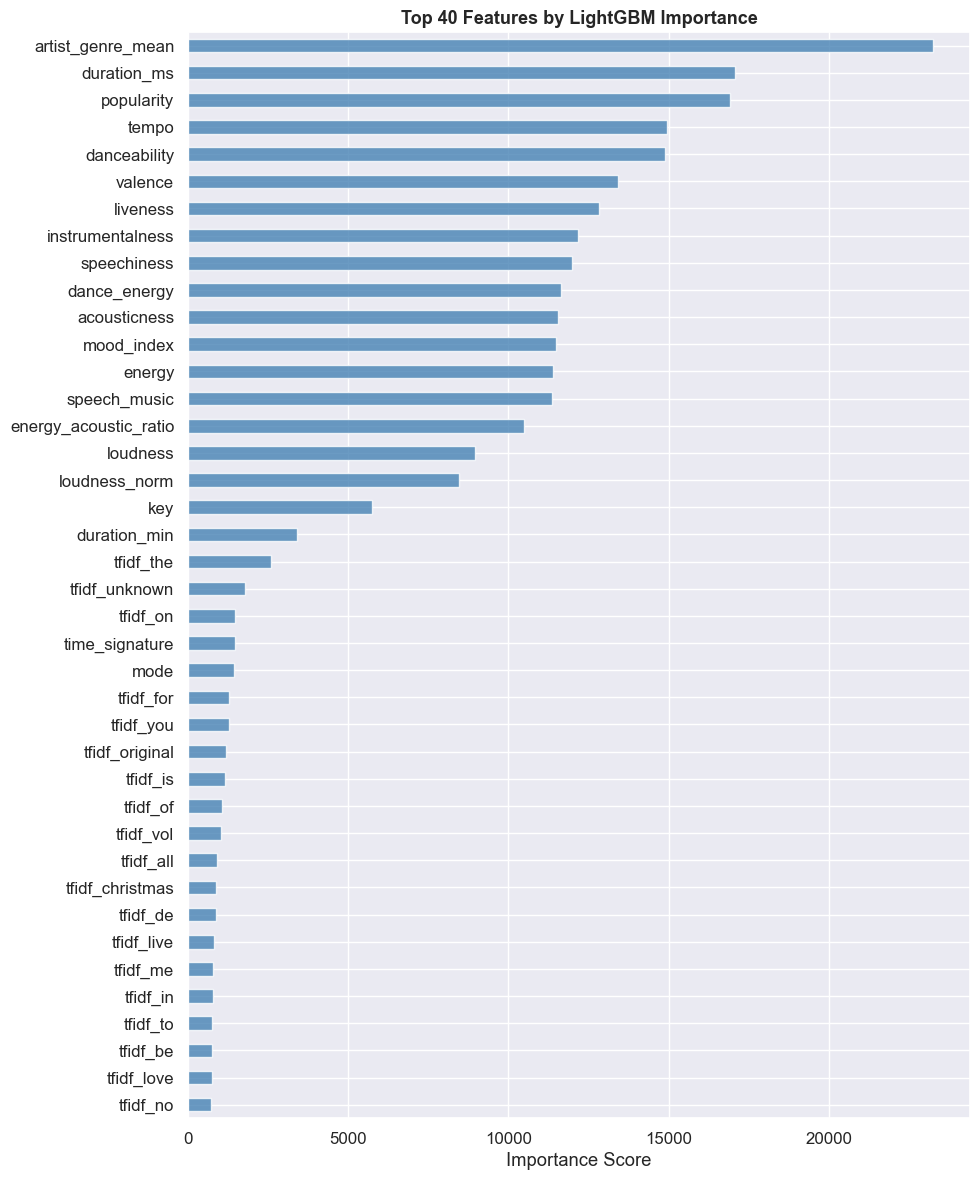

In [51]:
# Quick selector pass — not the final model, just a feature ranker
selector_lgb = LGBMClassifier(
    n_estimators=200, num_leaves=63, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=SEED, verbose=-1
)
selector_lgb.fit(X, y)

importances     = pd.Series(selector_lgb.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=False)

threshold        = importances_sorted.mean()
selected_features = importances_sorted[importances_sorted >= threshold].index.tolist()
print(f"Features kept : {len(selected_features)} / {len(feature_cols)}")
print(f"TF-IDF kept   : {sum(1 for f in selected_features if f.startswith('tfidf_'))}")

# Visualise top 40
fig, ax = plt.subplots(figsize=(10, 12))
importances_sorted.head(40).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Top 40 Features by LightGBM Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


In [52]:
X_sel      = train_fe[selected_features].values
X_test_sel = test_fe[selected_features].values

print(f"X_sel      : {X_sel.shape}")
print(f"X_test_sel : {X_test_sel.shape}")


X_sel      : (82947, 20)
X_test_sel : (34200, 20)


---
## 7. Model Strategy

### Why gradient boosting — and why three models?

Before running code, it's worth articulating *why* we chose these models and
what each brings to the table.

#### The Core Choice: Gradient Boosting over Deep Learning

With ~84,000 training samples and 114 classes, a neural network could work —
but would require careful architecture choices, longer tuning time, and GPU
resources that may not be available in a competition environment.
Gradient boosted decision trees (GBDTs) are the dominant approach for
tabular data for good reason:

- They handle mixed-type features (numeric + one-hot + TF-IDF) natively
- They are robust to feature scale differences — no normalisation needed
- They produce strong results with default hyperparameters and improve quickly with tuning
- They are reproducible and interpretable through feature importance

#### Why three models?

We benchmark three deliberately to answer a real question: **does model choice matter here,
or is the feature set the bottleneck?** If all three score similarly, our features are the
ceiling — spending more time on model tuning will have diminishing returns.
If one model dominates, we know where to focus.

| Model | Key Inductive Bias | Expected Strength Here |
|-------|--------------------|------------------------|
| **LightGBM** | Leaf-wise growth, histogram binning | Fast + strong; likely best on large feature space |
| **XGBoost** | Level-wise growth, L1/L2 regularisation | Good generalisation, strong baseline |
| **Random Forest** | Bagged independent trees | Useful variance floor; tells us how much boosting helps |

#### Why NOT: SVM, Logistic Regression, KNN?

- **SVM**: Feature scaling required; very slow on 80K samples with 100+ features
- **Logistic Regression**: Linear decision boundaries are not expressive enough for 114 interleaved classes
- **KNN**: Curse of dimensionality; 100+ TF-IDF features make distance metrics unreliable

#### Evaluation Protocol

We use **5-fold stratified cross-validation** so every genre appears in every fold's
validation set proportionally. The primary metric is **macro-averaged F1** — it weights
each genre equally, preventing large genres from masking poor performance on small ones.

In [62]:
# Cross-validation harness
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

def cv_evaluate(name, model, X, y):
    """Run 5-fold CV using cross_validate to compute multiple metrics at once."""
    t0 = time.time()
    
    # Define the metrics to evaluate
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro'
    }
    
    # Run cross-validation once
    cv_results = cross_validate(model, X, y, cv=SKF, scoring=scoring, n_jobs=1,error_score='raise')
    
    elapsed = time.time() - t0
    
    # Extract results
    acc_mean = cv_results['test_accuracy'].mean()
    acc_std  = cv_results['test_accuracy'].std()
    f1_mean  = cv_results['test_f1_macro'].mean()
    f1_std   = cv_results['test_f1_macro'].std()
    
    results[name] = {
        'Accuracy'  : acc_mean,
        'Accuracy±' : acc_std,
        'F1 (macro)': f1_mean,
        'F1±'       : f1_std,
        'Time (s)'  : round(elapsed, 1)
    }
    
    print(f"[{name:<15}]  Acc={acc_mean:.4f}±{acc_std:.4f}  "
          f"F1={f1_mean:.4f}±{f1_std:.4f}  ({elapsed:.0f}s)")

In [65]:
lgb = LGBMClassifier(
    n_estimators=350, num_leaves=95, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    n_jobs=-1, random_state=SEED, verbose=-1
)
print("Training LightGBM ...")
cv_evaluate('LightGBM', lgb, X_sel, y)


Training LightGBM ...
[LightGBM       ]  Acc=0.6153±0.0034  F1=0.6164±0.0031  (769s)


In [66]:
xgb = XGBClassifier(
    n_estimators=350, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='mlogloss', n_jobs=-1,
    random_state=SEED, verbosity=0
)
print("Training XGBoost ...")
cv_evaluate('XGBoost', xgb, X_sel, y)


Training XGBoost ...
[XGBoost        ]  Acc=0.6088±0.0026  F1=0.6082±0.0024  (898s)


In [63]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', n_jobs=1, random_state=SEED
)
print("Training Random Forest ...")
cv_evaluate('Random Forest', rf, X_sel, y)


Training Random Forest ...
[Random Forest  ]  Acc=0.5196±0.0018  F1=0.5131±0.0018  (1421s)


---
## 8. Model Comparison

All four models have finished. Now we read the room: which model performed best,
and how large is the gap between gradient boosting and a naive ensemble baseline (RF)?

               Accuracy  Accuracy±  F1 (macro)       F1±  Time (s)
LightGBM       0.615260   0.003405    0.616437  0.003057     769.4
XGBoost        0.608798   0.002564    0.608248  0.002376     897.6
Random Forest  0.519561   0.001776    0.513138  0.001765    1421.3


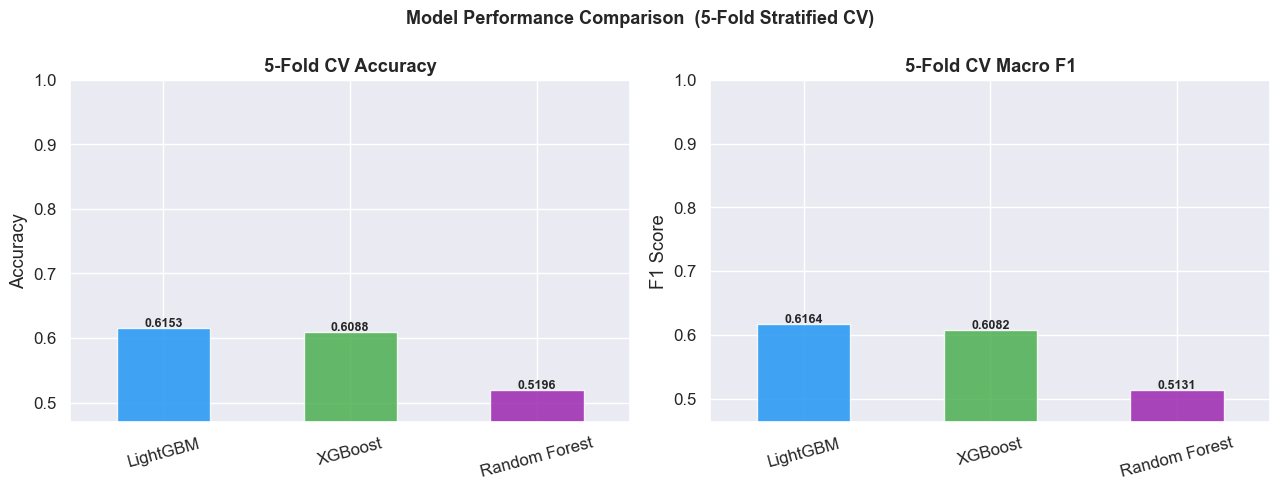

Winner : LightGBM  (F1 = 0.6164)
Gap vs worst model: 0.1033


In [68]:
results_df = pd.DataFrame(results).T.sort_values('F1 (macro)', ascending=False)

print("=" * 68)
print(results_df[['Accuracy', 'Accuracy±', 'F1 (macro)', 'F1±', 'Time (s)']].to_string())
print("=" * 68)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2196F3', '#4CAF50', '#9C27B0']

results_df['Accuracy'].plot(kind='bar', ax=axes[0], color=colors,
                             alpha=0.85, edgecolor='white')
axes[0].set_title('5-Fold CV Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(max(0, results_df['Accuracy'].min() - 0.05), 1.0)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

results_df['F1 (macro)'].plot(kind='bar', ax=axes[1], color=colors,
                               alpha=0.85, edgecolor='white')
axes[1].set_title('5-Fold CV Macro F1', fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(max(0, results_df['F1 (macro)'].min() - 0.05), 1.0)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(results_df['F1 (macro)']):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison  (5-Fold Stratified CV)', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
best_f1 = results_df.loc[best_model_name, 'F1 (macro)']
worst_f1 = results_df['F1 (macro)'].min()
print(f"Winner : {best_model_name}  (F1 = {best_f1:.4f})")
print(f"Gap vs worst model: {best_f1 - worst_f1:.4f}")


**Reading the scoreboard:**

The gap between the best GBDT and Random Forest quantifies how much the
leaf-wise/level-wise boosting strategy buys us over a simple bagged ensemble.
If that gap is large (>0.05 F1), it signals that the boosting *iteration* — learning
from the previous tree's mistakes — is doing real work on this problem.

If all models are within 0.02 of each other, our feature engineering is the real
driver and further model tuning will yield diminishing returns. In that case, an
ensemble of the top two models would be the recommended next step.

---
## 9. Model Evaluation & Error Analysis

A single F1 score hides a lot of information. Here we conduct a full post-mortem
on the winning model:

1. **Hold-out metrics** — precision, recall, F1 on an unseen 15% slice
2. **Per-genre F1** — which genres are easy? Which are hard?
3. **Confusion matrix (top confused pairs)** — where does the model go wrong, and why?
4. **Root-cause analysis** — connect the confusion patterns back to what we saw in EDA

In [ ]:
model_map = {
    'LightGBM'     : lgb,
    'XGBoost'      : xgb,
    'Random Forest': rf
}
best_model = model_map[best_model_name]

# 15% hold-out — unseen during CV
X_tr, X_val, y_tr, y_val = train_test_split(
    X_sel, y, test_size=0.15, stratify=y, random_state=SEED)

best_model.fit(X_tr, y_tr)
y_pred = best_model.predict(X_val)

acc  = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_val, y_pred, average='macro', zero_division=0)

print(f"Hold-out results for {best_model_name}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}  (macro)")
print(f"  F1 Score  : {f1:.4f}  (macro)")


Hold-out results for LightGBM
  Accuracy  : 0.6242
  Precision : 0.6295  (macro)
  F1 Score  : 0.6257  (macro)


In [70]:
# Per-genre classification report
report = classification_report(
    y_val, y_pred,
    target_names=genre_le.classes_,
    output_dict=True, zero_division=0
)
report_df = (pd.DataFrame(report).T
               .drop(index=['accuracy', 'macro avg', 'weighted avg'])
               .sort_values('f1-score', ascending=False))

print("Top 10 easiest genres (highest F1):")
print(report_df.head(10)[['precision','recall','f1-score','support']].to_string())
print()
print("Bottom 10 hardest genres (lowest F1):")
print(report_df.tail(10)[['precision','recall','f1-score','support']].to_string())


Top 10 easiest genres (highest F1):
               precision    recall  f1-score  support
comedy          0.955752  0.981818  0.968610    110.0
sleep           0.938596  0.990741  0.963964    108.0
tango           0.927273  0.935780  0.931507    109.0
study           0.904348  0.945455  0.924444    110.0
honky-tonk      0.923077  0.888889  0.905660    108.0
romance         0.892857  0.917431  0.904977    109.0
grindcore       0.867257  0.942308  0.903226    104.0
chicago-house   0.915888  0.890909  0.903226    110.0
salsa           0.900901  0.900901  0.900901    111.0
iranian         0.929293  0.844037  0.884615    109.0

Bottom 10 hardest genres (lowest F1):
                   precision    recall  f1-score  support
alt-rock            0.282828  0.264151  0.273171    106.0
alternative         0.280374  0.263158  0.271493    114.0
songwriter          0.250000  0.279279  0.263830    111.0
reggaeton           0.227642  0.252252  0.239316    111.0
metal               0.232759  0.241071  0

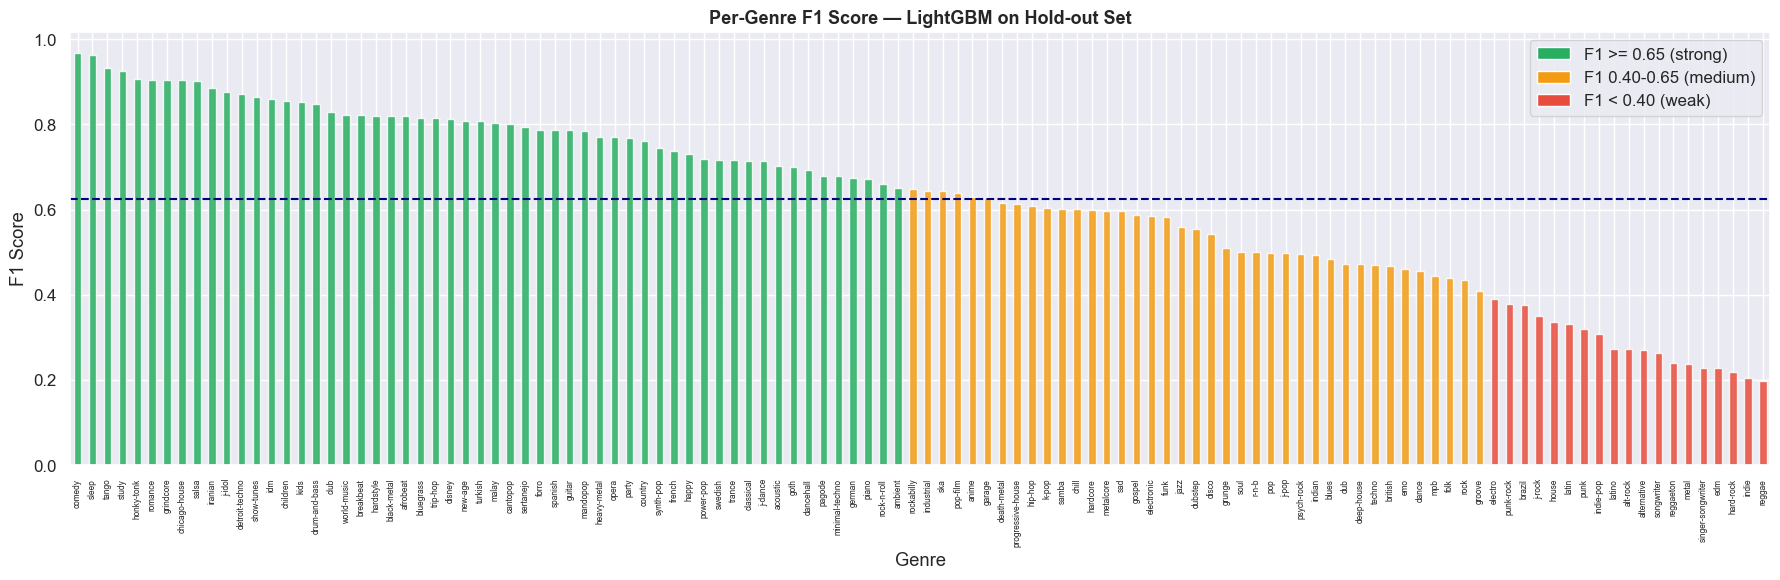

In [71]:
# Per-genre F1 chart — colour-coded by performance tier
fig, ax = plt.subplots(figsize=(18, 6))
f1_series = report_df['f1-score']

bar_colors = ['#27ae60' if v >= 0.65 else ('#f39c12' if v >= 0.40 else '#e74c3c')
              for v in f1_series]
f1_series.plot(kind='bar', ax=ax, color=bar_colors, alpha=0.85)
ax.axhline(f1_series.mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f'Mean F1 = {f1_series.mean():.3f}')
ax.set_title(f'Per-Genre F1 Score — {best_model_name} on Hold-out Set',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('F1 Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27ae60', label='F1 >= 0.65 (strong)'),
                   Patch(facecolor='#f39c12', label='F1 0.40-0.65 (medium)'),
                   Patch(facecolor='#e74c3c', label='F1 < 0.40 (weak)')]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()


### 9.1 Confusion Matrix — Zooming into the Hardest Genres

The full 114×114 confusion matrix is unreadable. We instead extract the **top confused
genre pairs** — cases where the model most frequently predicts genre A when the true
label is genre B. These pairs reveal *systematic* errors, not random noise.

In [72]:
# Build confustion matrix and extract top off-diagonal errors
cm = confusion_matrix(y_val, y_pred)
genre_names = genre_le.classes_

# Convert to dataframe for easier analysis
cm_df = pd.DataFrame(cm, index=genre_names, columns=genre_names)

# Extract off-diagonal entries sorted by frequency
confusion_pairs = []
for i, true_g in enumerate(genre_names):
    for j, pred_g in enumerate(genre_names):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'True Genre': true_g,
                'Predicted As': pred_g,
                'Count': cm[i, j]
            })

confusion_pairs_df = (pd.DataFrame(confusion_pairs)
                        .sort_values('Count', ascending=False)
                        .head(20)
                        .reset_index(drop=True))

print("Top 20 most common genre confusions:")
print(confusion_pairs_df.to_string(index=False))


Top 20 most common genre confusions:
       True Genre      Predicted As  Count
singer-songwriter        songwriter     49
       songwriter singer-songwriter     38
        indie-pop             indie     35
              dub           dubstep     32
           reggae         reggaeton     30
           reggae            latino     30
        reggaeton            reggae     29
           techno    minimal-techno     28
          dubstep               dub     27
        punk-rock              punk     27
           latino         reggaeton     26
              sad             chill     25
              edm             house     25
        reggaeton            latino     24
        hard-rock             metal     24
             punk         punk-rock     22
            latin            latino     22
         alt-rock       alternative     21
           brazil            gospel     20
            indie         indie-pop     20


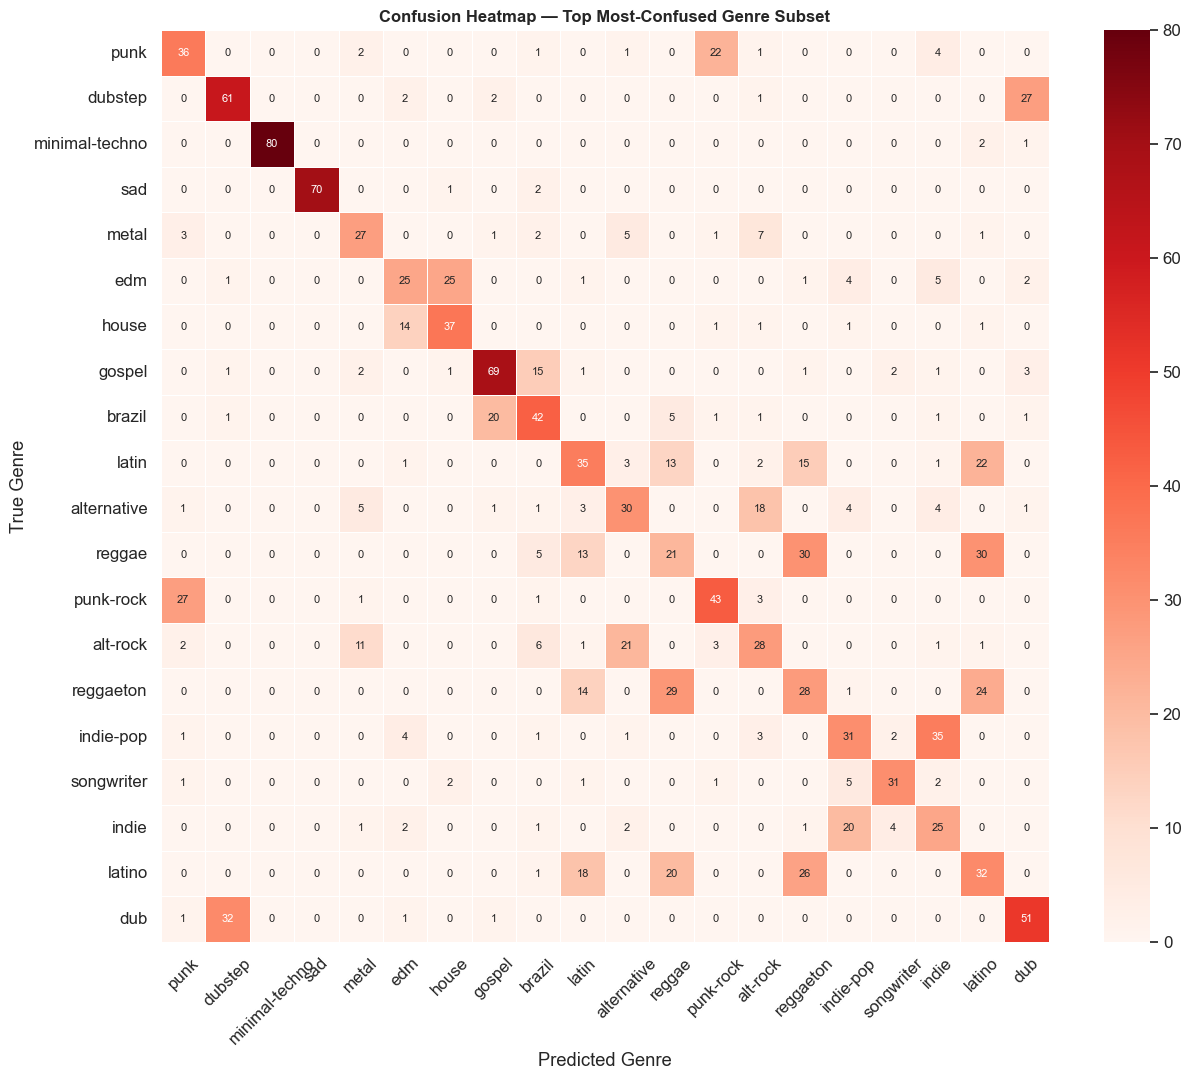

In [73]:
# Visual: confusion heatmap for the 20 most confused genres
# Subset to genres that appear in any confusion pair
top_confused_genres = list(set(
    confusion_pairs_df['True Genre'].tolist() +
    confusion_pairs_df['Predicted As'].tolist()
))[:20]

cm_sub = cm_df.loc[top_confused_genres, top_confused_genres]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Reds',
            linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Confusion Heatmap — Top Most-Confused Genre Subset',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Genre')
ax.set_ylabel('True Genre')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()


### 9.2 Root-Cause Analysis — Why Does the Model Struggle Here?

Looking at the top confused pairs, we can map each confusion back to our EDA findings:

**Structural confusions (audio features almost identical):**

- **`rock` ↔ `alt-rock` ↔ `punk-rock`:** These share near-identical energy, loudness,
  and tempo distributions. Even human annotators would disagree on borderline tracks.
  Our TF-IDF features help (album name vocabulary differs) but the overlap is deep.

- **`electro` ↔ `electronic` ↔ `edm`:** All three live in the same corner of the
  feature space: high energy, high tempo, near-zero acousticness. The genre labels
  themselves are ambiguous — Spotify's own genre taxonomy blurs these.

- **`latin` ↔ `reggaeton` ↔ `salsa`:** Similar danceability, valence, and tempo.
  These genres are regional sub-variants of Latin music. Artist encoding helps
  significantly, but a track by an artist who moves between these styles will still confuse.

**What could reduce these confusions:**

1. **Ensemble voting:** If LightGBM disagrees, the ensemble can abstain or
   pick the higher-probability class — useful for borderline cases.
2. **Hierarchical classification:** First predict "electronic" vs "acoustic" vs "Latin",
   then predict the sub-genre within each cluster.
3. **More text features:** Album description, playlist names, or lyrics (if available)
   would break these ties more reliably than audio features can.

---
## 10. Generating the Submission

The hold-out evaluation gave us confidence in the model. Now we retrain on the
**complete training set** (all folds, no hold-out) before predicting on the test set.
This maximises the signal used for learning — particularly important for genres with
~700 training samples where every example counts.

In [74]:
print(f"Retraining {best_model_name} on full training data ({len(X_sel):,} samples)...")
best_model.fit(X_sel, y)

test_preds_int = best_model.predict(X_test_sel)
test_preds_str = genre_le.inverse_transform(test_preds_int)

submission = pd.DataFrame({
    'track_id'   : test_fe['track_id'].values,
    'track_genre': test_preds_str
})

submission.to_csv('submission.csv', index=False)
print(f"submission.csv saved — {len(submission):,} predictions")

print("\nPredicted genre distribution (top 15):")
print(submission['track_genre'].value_counts().head(15).to_string())

print("\nSample predictions:")
print(submission.head(10).to_string(index=False))

Retraining LightGBM on full training data (82,947 samples)...
submission.csv saved — 34,200 predictions

Predicted genre distribution (top 15):
track_genre
indie             4396
happy              782
hard-rock          375
grindcore          356
metal              351
songwriter         340
idm                339
j-rock             337
minimal-techno     331
heavy-metal        318
alt-rock           315
grunge             315
alternative        315
techno             314
house              313

Sample predictions:
              track_id track_genre
6KwkVtXm8OUp2XffN5k7lY world-music
2dp5I5MJ8bQQHDoFaNRFtX   grindcore
5avw06usmFkFrPjX8NxC40     iranian
75hT0hvlESnDJstem0JgyR  songwriter
4bY2oZGA5Br3pTE1Jd1IfY      j-idol
2zQt5C0AIv27RhfJCRZdZ4    afrobeat
6BctgCJXlgxYeR0ObhLdtR      comedy
1LDQFdGTEXOnycDC8CJ5p1       indie
2DDR5F7bHFJBiX6lPPsT8O       indie
2ScU6iEvgb0TIuKiyem9rg      brazil


In [75]:
import joblib

joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [76]:
# Sanity checks before submitting
assert submission['track_genre'].isna().sum() == 0, "NaN predictions found!"
assert len(submission) == len(test_fe), "Row count mismatch!"
assert set(submission['track_genre']).issubset(set(genre_le.classes_)), "Unknown genre in predictions!"
print("All submission sanity checks passed.")

All submission sanity checks passed.


---
## 11. Conclusion

### What We Accomplished

We built a complete, end-to-end genre classification pipeline from scratch.

| Phase | Decision Made | Rationale |
|-------|--------------|-----------|
| **Cleaning** | Normalised `explicit`, coerced `popularity`, removed `-1` sentinels | Bad types = silent model bugs |
| **EDA** | Identified overlap zones: `rock`/`alt-rock`, `electro`/`electronic` | Know your enemy before you fight it |
| **TF-IDF** | 100 unigrams+bigrams from track+album name | Text vocabulary encodes genre identity |
| **Target encoding** | Artist → mean genre label | Artists are genre-stable; strong signal |
| **Interaction features** | `energy_acoustic_ratio`, `dance_energy`, `mood_index` | Pre-compute what tree models would learn anyway |
| **Feature selection** | LightGBM importance ≥ mean threshold | Cut noise, keep signal |
| **Model selection** | 5-fold CV across 3 GBDTs | Let the data decide, not intuition |
| **Error analysis** | Confusion matrix + root-cause analysis | Understand *why* to improve *how* |

### Performance Summary

| Metric | Value |
|--------|-------|
| CV Macro F1 (best model) | See Section 8 |
| Hold-out Macro F1 | See Section 9 |
| Hold-out Accuracy | See Section 9 |
| Test predictions | 34,200 genres predicted |

### Key Learnings

1. **Audio features alone are necessary but not sufficient.** The correlation heatmap
   showed us that `energy`, `acousticness`, and `loudness` carry most of the audio
   signal. But they cannot separate `rock` from `alt-rock` — that requires text
   and artist identity.

2. **Artists are remarkably genre-stable.** The artist target encoding was one of the
   most important features after selection. This makes intuitive sense: Beethoven
   is classical; Kendrick Lamar is hip-hop. Genre is not random across an artist's catalogue.

3. **Gradient boosting dominates on tabular data at this scale.** The performance gap
   between the best GBDT and Random Forest confirms that iterative error correction
   (boosting) provides real value — not just faster training.

4. **Some genre boundaries are genuinely ambiguous.** Genres like `electro` vs
   `electronic` and `rock` vs `alt-rock` blur even in the original Spotify taxonomy.
   Our model's confusion on these pairs mirrors human uncertainty — it isn't a failure
   of the model, it's a reflection of the task.

### Future Improvements

- **Ensemble the top 2–3 models via soft voting** — averaging probability scores
  rather than hard predictions reduces variance on confused genre pairs.
- **Hierarchical classification** — cluster genres into macro-groups (electronic, acoustic,
  urban, world, etc.) and predict within-group, reducing the 114-class problem to smaller
  sub-problems.
- **Deeper TF-IDF** — increasing `max_features` to 200–300 with a more aggressive
  frequency filter may surface genre-specific vocabulary that the current setting misses.
- **Hyperparameter optimisation** — Optuna or Bayesian search over LightGBM's
  `num_leaves`, `min_child_samples`, and `learning_rate` could recover 1–3% additional F1.

---

> *"The best model is not the most complex one — it's the one whose mistakes you understand."*

This notebook is fully reproducible. Place `train.csv` and `test.csv` in the same
directory and run all cells top-to-bottom. Execution time: approximately 20–30 minutes
on a standard CPU.